# FMCG Sales Analysis and Forecasting Project
We are using Linear regression to forecast sales for the year 2024 using the sales for 2023

In [69]:
# Importing libabries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split

In [70]:
# Opening the dataframe
FMCG_df = pd.read_csv('fmcg_sales_3years_1M_rows.csv')

# Set max columns
pd.set_option("display.max_columns", None)

# Displaying the first 5 rows
FMCG_df.head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,16,10.49,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,12,10.49,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,38,10.49,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,8,10.49,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,17,10.49,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


# Forecasting (Statistics + Machine Learning)
Forecast 10 SKUs with different demand profiles.

In [71]:
# Creating a df for seeing which products are promo driven
sku_stats = FMCG_df.groupby('sku_name').agg(
    mean_sales=('units_sold','mean'),
    std_sales=('units_sold','std'),
    cv_sales=('units_sold', lambda x: x.std()/x.mean()),
    promo_uplift=('units_sold', lambda x: x[FMCG_df['promo_flag']==1].mean() / x.mean())
).reset_index()
sku_stats

,sku_name,mean_sales,std_sales,cv_sales,promo_uplift
0,BrandA Biscuits,84.247073,35.119650,0.416865,NaN
1,BrandA Cheese,88.853699,35.153635,0.395635,NaN
2,BrandA Chips,24.036115,10.046344,0.417969,NaN
3,BrandA Chocolate,43.371598,25.204041,0.581119,1.603652
4,BrandA Cleaner,92.448858,45.592056,0.493160,1.590867
...,...,...,...,...,...
97,BrandF Soda,126.497336,68.803009,0.543909,1.574070
98,BrandF Softener,29.713141,11.020407,0.370893,NaN
99,BrandF Toothpaste,104.398376,54.345511,0.520559,1.601299
100,BrandF Water,97.387464,40.956221,0.420549,NaN


In [72]:
# Example thresholds (tune based on your data distribution)
cv_threshold_stable = 0.3       # CV < 0.3 → stable demand X
cv_threshold_volatile = 0.8     # CV > 0.8 → volatile demand - spikes or drops unexpectedly
promo_threshold = 1.2           # promo uplift > 1.2 → promo-driven
top_percentile = 0.8            # top 20% → high-value

# Add classification columns
sku_stats['demand_profile'] = np.where(
    sku_stats['cv_sales'] < cv_threshold_stable, 'Stable (X)',
    np.where(sku_stats['cv_sales'] > cv_threshold_volatile, 'Volatile (Z)', 'Seasonal (Y)')
)

sku_stats['promo_profile'] = np.where(
    sku_stats['promo_uplift'] > promo_threshold, 'Promo-driven', 'Not promo-driven'
)

# Rank SKUs by mean sales to classify high vs low value
sku_stats['sales_rank'] = sku_stats['mean_sales'].rank(pct=True)

sku_stats['value_profile'] = np.where(
    sku_stats['sales_rank'] >= top_percentile, 'High-value (A)', 'Low-value (C)'
)

# Final classification table
print(sku_stats[['sku_name','demand_profile','promo_profile','value_profile']])


              sku_name demand_profile     promo_profile   value_profile
0      BrandA Biscuits   Seasonal (Y)  Not promo-driven   Low-value (C)
1        BrandA Cheese   Seasonal (Y)  Not promo-driven   Low-value (C)
2         BrandA Chips   Seasonal (Y)  Not promo-driven   Low-value (C)
3     BrandA Chocolate   Seasonal (Y)      Promo-driven   Low-value (C)
4       BrandA Cleaner   Seasonal (Y)      Promo-driven  High-value (A)
..                 ...            ...               ...             ...
97         BrandF Soda   Seasonal (Y)      Promo-driven  High-value (A)
98     BrandF Softener   Seasonal (Y)  Not promo-driven   Low-value (C)
99   BrandF Toothpaste   Seasonal (Y)      Promo-driven  High-value (A)
100       BrandF Water   Seasonal (Y)  Not promo-driven  High-value (A)
101      BrandF Yogurt   Seasonal (Y)      Promo-driven  High-value (A)

[102 rows x 4 columns]


# Machine learning

In [73]:
# Creating a df for key features for the ML
supervised_data = FMCG_df.groupby(['date','sku_name'])['units_sold'].sum().reset_index()
supervised_data

,date,sku_name,units_sold
0,2021-01-01,BrandA Biscuits,798
1,2021-01-01,BrandA Cheese,810
2,2021-01-01,BrandA Chips,237
3,2021-01-01,BrandA Chocolate,399
4,2021-01-01,BrandA Cleaner,409
...,...,...,...
111685,2023-12-31,BrandF Soda,1378
111686,2023-12-31,BrandF Softener,310
111687,2023-12-31,BrandF Toothpaste,1846
111688,2023-12-31,BrandF Water,1215


In [74]:
# Droping SKU name since the model can't read string values
supervised_data = supervised_data.drop(['sku_name'], axis=1)
supervised_data

,date,units_sold
0,2021-01-01,798
1,2021-01-01,810
2,2021-01-01,237
3,2021-01-01,399
4,2021-01-01,409
...,...,...
111685,2023-12-31,1378
111686,2023-12-31,310
111687,2023-12-31,1846
111688,2023-12-31,1215


In [75]:
# Displaying the info of the df
supervised_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111690 entries, 0 to 111689
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        111690 non-null  object
 1   units_sold  111690 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.7+ MB


In [76]:
# Changing the date from object to datetime for our model to understand its a time series data
supervised_data['date'] = pd.to_datetime(supervised_data['date'])

In [77]:
# Displaying the info, to confirm if the date has been changed
supervised_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111690 entries, 0 to 111689
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        111690 non-null  datetime64[ns]
 1   units_sold  111690 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.7 MB


<function matplotlib.pyplot.show(close=None, block=None)>

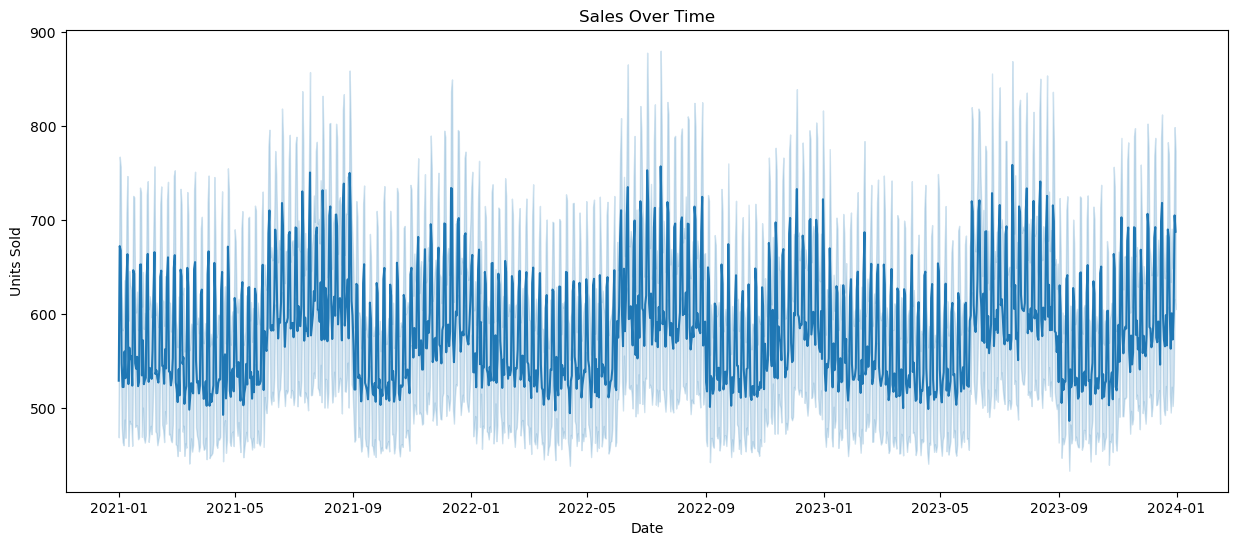

In [78]:
# Plotting a line plot for the date and the units sold across the 3 years
plt.figure(figsize=(15,6))
sns.lineplot(x='date', y='units_sold', data=supervised_data)
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show

In [79]:
# Converting the datetime to TimestampDtype first making column robust to multiple executions.
if isinstance(supervised_data['date'].dtype, pd.PeriodDtype):
    supervised_data['date'] = supervised_data['date'].dt.to_timestamp()

#  converting the date column to Period[M]
supervised_data['date'] = supervised_data['date'].dt.to_period('M')

In [80]:
# Displaying the df
Monthly_sales=supervised_data.groupby('date')['units_sold'].sum().reset_index()
Monthly_sales

,date,units_sold
0,2021-01,1820815
1,2021-02,1627648
2,2021-03,1746833
3,2021-04,1695518
4,2021-05,1766192
5,2021-06,1883342
6,2021-07,1978893
7,2021-08,2002722
8,2021-09,1684090
9,2021-10,1766916


In [81]:
# Displaying the df
Monthly_sales=supervised_data.groupby('date')['units_sold'].sum().reset_index()
Monthly_sales

,date,units_sold
0,2021-01,1820815
1,2021-02,1627648
2,2021-03,1746833
3,2021-04,1695518
4,2021-05,1766192
5,2021-06,1883342
6,2021-07,1978893
7,2021-08,2002722
8,2021-09,1684090
9,2021-10,1766916


In [82]:
Monthly_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype    
---  ------      --------------  -----    
 0   date        36 non-null     period[M]
 1   units_sold  36 non-null     int64    
dtypes: int64(1), period[M](1)
memory usage: 704.0 bytes


<function matplotlib.pyplot.show(close=None, block=None)>

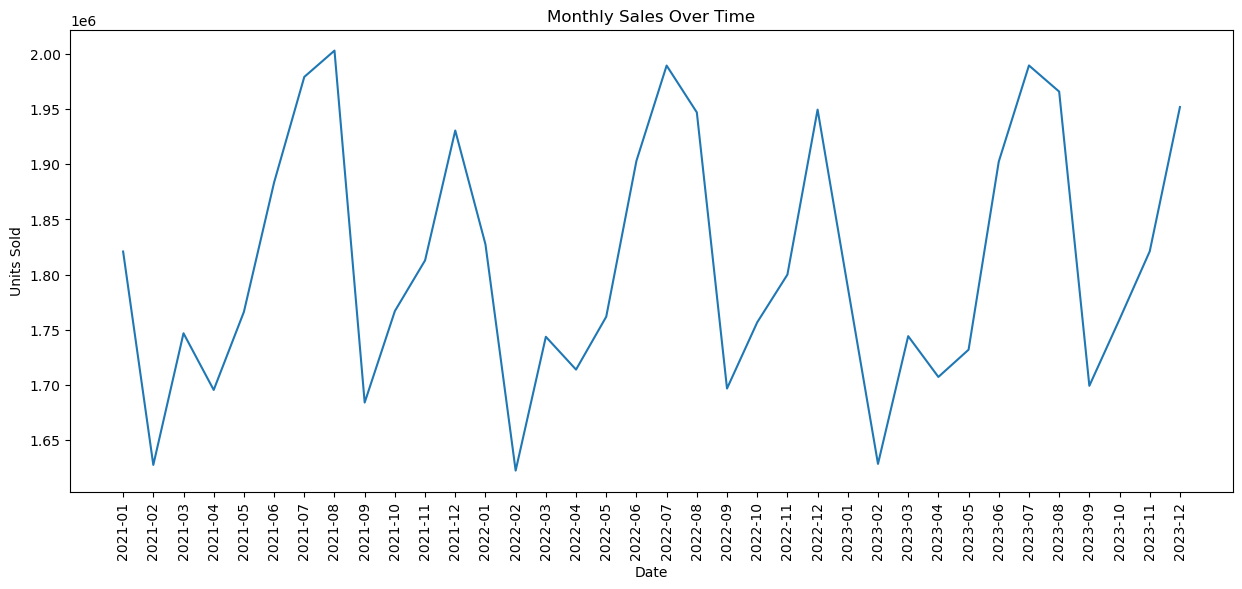

In [83]:
#Convert Period objects back to Datetime timestamps
Monthly_sales['date'] = Monthly_sales['date'].astype(str)

# Ploting a graph of monthly sales accross the 3 years
plt.figure(figsize=(15,6))
sns.lineplot(x='date', y='units_sold', data=Monthly_sales)
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.xticks(rotation=90) # Add rotation to the x-axis tick labels (the dates)
plt.savefig("Outputs/Monthly Sales Over Time.png") # Saving the graph ad png
plt.show

In [84]:
# Getting the sales difference for each month
Monthly_sales['sales_diff'] = Monthly_sales['units_sold'].diff()

# Dropping the missing values ie. January
Monthly_sales = Monthly_sales.dropna()
Monthly_sales

,date,units_sold,sales_diff
1,2021-02,1627648,-193167.0
2,2021-03,1746833,119185.0
3,2021-04,1695518,-51315.0
4,2021-05,1766192,70674.0
5,2021-06,1883342,117150.0
6,2021-07,1978893,95551.0
7,2021-08,2002722,23829.0
8,2021-09,1684090,-318632.0
9,2021-10,1766916,82826.0
10,2021-11,1812806,45890.0


C:\Users\HomePC\AppData\Local\Temp\ipykernel_67892\1603422992.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Monthly_sales['date'] = Monthly_sales['date'].astype(str)


<function matplotlib.pyplot.show(close=None, block=None)>

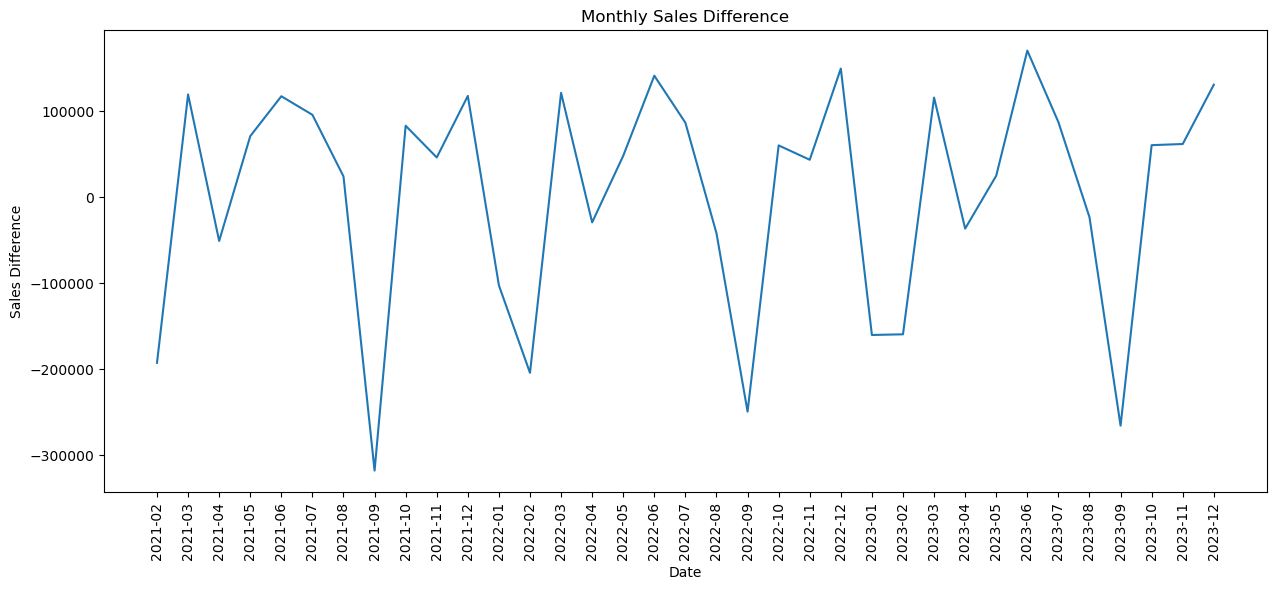

In [85]:
#Convert Period objects back to Datetime timestamps
Monthly_sales['date'] = Monthly_sales['date'].astype(str)

# Plotting a line graph for the sales difference
plt.figure(figsize=(15,6))
plt.plot(Monthly_sales['date'], Monthly_sales['sales_diff'])
plt.title('Monthly Sales Difference')
plt.xlabel('Date')
plt.ylabel('Sales Difference')
plt.xticks(rotation=90)
plt.savefig("Outputs/Monthly Sales Difference.png")  # Saving the plot as png
plt.show

In [86]:
# Droping the date and units sold and remaining with sales df
Supervised_data = Monthly_sales.drop(['date','units_sold'], axis=1)
Supervised_data

,sales_diff
1,-193167.0
2,119185.0
3,-51315.0
4,70674.0
5,117150.0
6,95551.0
7,23829.0
8,-318632.0
9,82826.0
10,45890.0


In [87]:
for i in range(1,13):
  col_name = 'M' + str(i)
  Supervised_data[col_name] = Supervised_data['sales_diff'].shift(i)
Supervised_data = Supervised_data.dropna().reset_index(drop=True)
Supervised_data

,sales_diff,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
0,-204839.0,-103027.0,117561.0,45890.0,82826.0,-318632.0,23829.0,95551.0,117150.0,70674.0,-51315.0,119185.0,-193167.0
1,121150.0,-204839.0,-103027.0,117561.0,45890.0,82826.0,-318632.0,23829.0,95551.0,117150.0,70674.0,-51315.0,119185.0
2,-29706.0,121150.0,-204839.0,-103027.0,117561.0,45890.0,82826.0,-318632.0,23829.0,95551.0,117150.0,70674.0,-51315.0
3,47870.0,-29706.0,121150.0,-204839.0,-103027.0,117561.0,45890.0,82826.0,-318632.0,23829.0,95551.0,117150.0,70674.0
4,141077.0,47870.0,-29706.0,121150.0,-204839.0,-103027.0,117561.0,45890.0,82826.0,-318632.0,23829.0,95551.0,117150.0
5,86283.0,141077.0,47870.0,-29706.0,121150.0,-204839.0,-103027.0,117561.0,45890.0,82826.0,-318632.0,23829.0,95551.0
6,-42384.0,86283.0,141077.0,47870.0,-29706.0,121150.0,-204839.0,-103027.0,117561.0,45890.0,82826.0,-318632.0,23829.0
7,-249991.0,-42384.0,86283.0,141077.0,47870.0,-29706.0,121150.0,-204839.0,-103027.0,117561.0,45890.0,82826.0,-318632.0
8,59916.0,-249991.0,-42384.0,86283.0,141077.0,47870.0,-29706.0,121150.0,-204839.0,-103027.0,117561.0,45890.0,82826.0
9,43200.0,59916.0,-249991.0,-42384.0,86283.0,141077.0,47870.0,-29706.0,121150.0,-204839.0,-103027.0,117561.0,45890.0


# Training the model

In [88]:
# Training the model
train_data = Supervised_data[:-12]
test_data = Supervised_data[-12:]
print(train_data.shape, test_data.shape)

(11, 13) (12, 13)


In [89]:
# Scaling the model
Scaler = MinMaxScaler(feature_range=(-1,1))
Scaler.fit(train_data)
train_data = Scaler.transform(train_data)
test_data = Scaler.transform(test_data)

In [90]:
X_train,y_train = train_data[:,1:], train_data[:,0:1]
X_test, y_test = test_data[:,1:], test_data[:,0:1]
y_train = y_train.ravel()
y_test = y_test.ravel()


In [91]:
# Creating a df where the predicted values will be stored (predict_df)
supervised_data_dates = Monthly_sales['date'][-12:].reset_index(drop=True)
predict_df = pd.DataFrame(supervised_data_dates)

predict_df

,date
0,2023-01
1,2023-02
2,2023-03
3,2023-04
4,2023-05
5,2023-06
6,2023-07
7,2023-08
8,2023-09
9,2023-10


In [92]:
# Displaying the actual sales
actual_sales = Monthly_sales['units_sold'][-13:].to_list()
print(actual_sales)

[1949305, 1788545, 1628565, 1744216, 1707277, 1731937, 1902228, 1989263, 1965591, 1699259, 1759471, 1821014, 1951627]


In [93]:
# Fitting our model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred


array([ 0.15948384, -0.9655361 ,  1.10118333,  0.02536322,  0.39954414,
        1.21683267,  0.56895011, -0.32937855, -0.54937006,  0.24736585,
        0.56408519,  1.09518903])

In [94]:
# Joining the lr_pred with the actual X test
lr_pred = lr_pred.reshape(-1,1)
lr_pred_test_set = np.concatenate([lr_pred, X_test],axis=1)
lr_pred_test_set = Scaler.inverse_transform(lr_pred_test_set)
lr_pred_test_set


array([[ -18453.67162534,  149389.        ,   43200.        ,
          59916.        , -249991.        ,  -42384.        ,
          86283.        ,  141077.        ,   47870.        ,
         -29706.        ,  121150.        , -204839.        ,
        -103027.        ],
       [-243108.90355597, -160760.        ,  149389.        ,
          43200.        ,   59916.        , -249991.        ,
         -42384.        ,   86283.        ,  141077.        ,
          47870.        ,  -29706.        ,  121150.        ,
        -204839.        ],
       [ 169594.29954098, -159980.        , -160760.        ,
         149389.        ,   43200.        ,   59916.        ,
        -249991.        ,  -42384.        ,   86283.        ,
         141077.        ,   47870.        ,  -29706.        ,
         121150.        ],
       [ -45236.2188893 ,  115651.        , -159980.        ,
        -160760.        ,  149389.        ,   43200.        ,
          59916.        , -249991.        ,  -42384

In [95]:
# Getting the predicted values snd storing them in predict_df
results_list =[]
for index in range(0,len(lr_pred_test_set)):
  results_list.append(lr_pred_test_set[index][0] + actual_sales[index])
lr_pred_series = pd.Series(results_list, name ='Linear Prediction')
predict_df = predict_df.merge(lr_pred_series, left_index=True, right_index=True)
predict_df

,date,Linear Prediction
0,2023-01,1.930851e+06
1,2023-02,1.545436e+06
2,2023-03,1.798159e+06
3,2023-04,1.698980e+06
4,2023-05,1.736761e+06
5,2023-06,1.924625e+06
6,2023-07,1.965541e+06
7,2023-08,1.873188e+06
8,2023-09,1.805586e+06
9,2023-10,1.698354e+06


In [96]:
# Calculating the MSE,MAE,R2
lr_mse = np.sqrt(mean_squared_error(predict_df['Linear Prediction'],Monthly_sales['units_sold'][-12:]))
lr_mae = mean_squared_error(predict_df['Linear Prediction'], Monthly_sales['units_sold'][-12:])
lr_r2 = r2_score(predict_df['Linear Prediction'], Monthly_sales['units_sold'][-12:])
print(f"Linear Regression MSE: {lr_mse:.2F}")
print(f"Linear Regression MAE: {lr_mae:.2F}")
print(f"Linear Regression R2: {lr_r2:.4F}\n")

Linear Regression MSE: 68456.28
Linear Regression MAE: 4686261883.38
Linear Regression R2: 0.7012



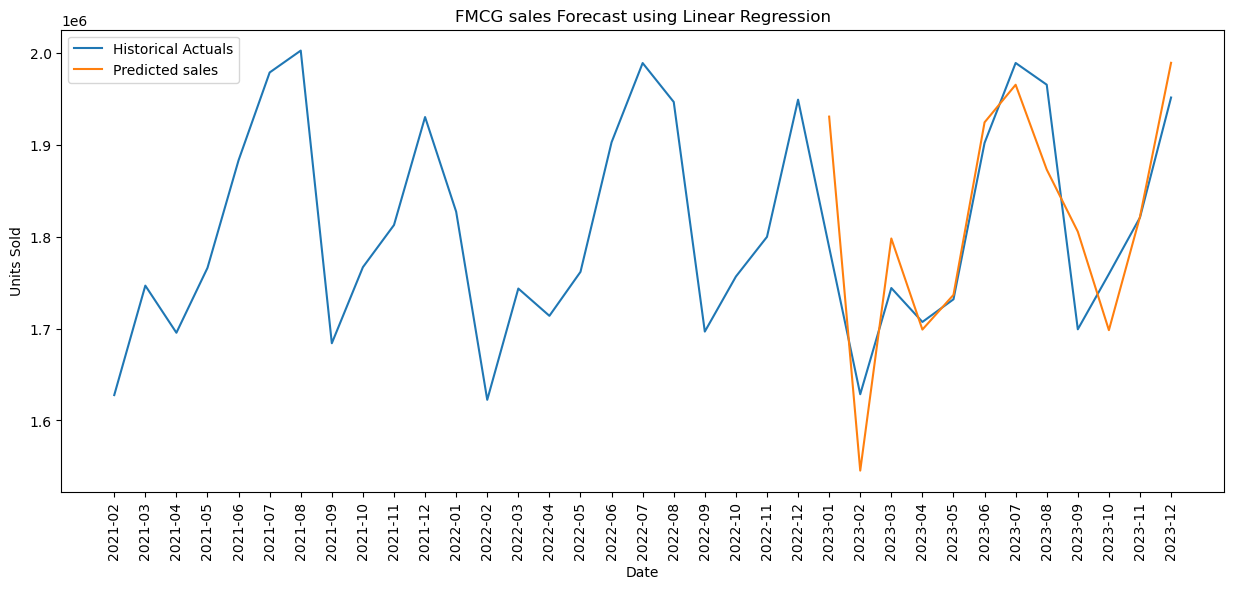

In [97]:
# Ploting a grph to validate our prediction
plt.figure(figsize=(15,6))
plt.plot(Monthly_sales['date'], Monthly_sales['units_sold'] ,label='Historical Actuals')
plt.plot(predict_df['date'], predict_df['Linear Prediction'], label='Predicted sales')
plt.title('FMCG sales Forecast using Linear Regression')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.xticks(rotation=90)
plt.legend(['Historical Actuals','Predicted sales'])
plt.savefig("Outputs/FMCG sales Forecast using Linear Regression.png")
plt.show()

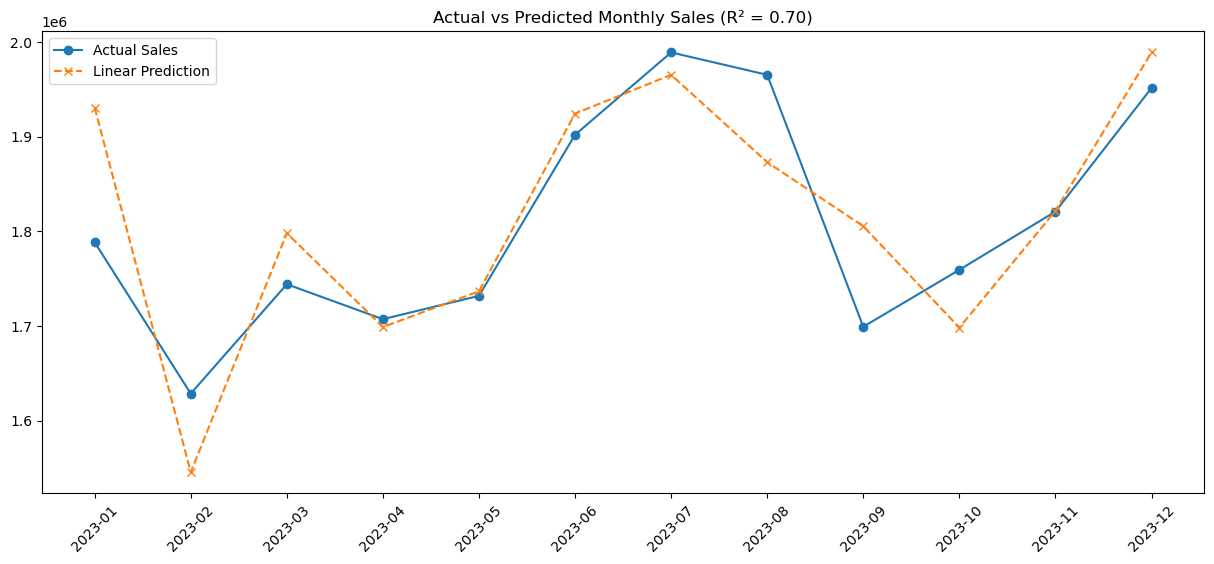

In [98]:
plt.figure(figsize=(15,6))
# Plot Actuals
plt.plot(predict_df['date'], Monthly_sales['units_sold'][-12:], label='Actual Sales', marker='o')
# Plot Predictions
plt.plot(predict_df['date'], predict_df['Linear Prediction'], label='Linear Prediction', linestyle='--', marker='x')

plt.title('Actual vs Predicted Monthly Sales (R² = 0.70)')
plt.legend()
plt.xticks(rotation=45)
plt.show()


In [99]:
# Prepare a new dataframe for 2024 dates
future_dates = pd.date_range(start='2024-01-01', periods=12, freq='MS')
forecast_df = pd.DataFrame({'date': future_dates})

# Initialize current_input_scaled_lags with the last known features (M1-M12)
# This comes from X_test, which was derived from test_data[:, 1:]
current_input_scaled_lags = X_test[-1].copy()

future_sales_diff_predictions_scaled = [] # To store the scaled sales_diff predictions

# Predcting the next sales diff using the current_input_scaled_lags
for i in range(12):
    next_pred_scaled_diff = lr_model.predict(current_input_scaled_lags.reshape(1, -1))[0]
    future_sales_diff_predictions_scaled.append(next_pred_scaled_diff)

    # Update current_input_scaled_lags for the next iteration, The new M1 is the predicted sales_diff for the current step.
    # The old M1 becomes M2, old M2 becomes M3, ..., old M11 becomes M12, the old M12 is dropped.

    current_input_scaled_lags = np.roll(current_input_scaled_lags, 1) # Shift elements to the right
    current_input_scaled_lags[0] = next_pred_scaled_diff # Place the new prediction at the front (as the new M1)

# To inverse transform, we need to reconstruct the 13-feature array (sales_diff, M1...M12) for each prediction.
# We need to inverse transform each next_pred_scaled_diff using the context of its corresponding lagged features.
full_scaled_rows_for_inverse_transform = []
current_input_for_reconstruction_lags = X_test[-1].copy() # Start from the last actual lags

for i in range(12):
    next_pred_scaled_diff = lr_model.predict(current_input_for_reconstruction_lags.reshape(1, -1))[0]

    # Construct the full 13-feature scaled row: [scaled_sales_diff, scaled_M1 to  scaled_M12]
    # np.insert inserts at index 0, so the new prediction is the first element
    full_scaled_row = np.insert(current_input_for_reconstruction_lags, 0, next_pred_scaled_diff)
    full_scaled_rows_for_inverse_transform.append(full_scaled_row)

    # Update current_input_for_reconstruction_lags for the next step
    current_input_for_reconstruction_lags = np.roll(current_input_for_reconstruction_lags, 1)
    current_input_for_reconstruction_lags[0] = next_pred_scaled_diff


# Inverse transform all collected 13-feature scaled rows
unscaled_full_predictions = Scaler.inverse_transform(np.array(full_scaled_rows_for_inverse_transform))

# The first column of unscaled_full_predictions contains the unscaled sales differences
future_sales_diff_unscaled = unscaled_full_predictions[:, 0]

# Accumulate the unscaled sales differences to get the actual forecasted sales values
last_actual_sales = Monthly_sales['units_sold'].iloc[-1]

forecasted_sales_values = []
current_forecasted_sales = last_actual_sales # Starting point for accumulation

for diff in future_sales_diff_unscaled:
    current_forecasted_sales += diff
    forecasted_sales_values.append(current_forecasted_sales)

forecast_df['Forecast_Sales'] = forecasted_sales_values

# Ensure non-negative predictions
forecast_df['Forecast_Sales'] = forecast_df['Forecast_Sales'].apply(lambda x: max(0, x))

display(forecast_df.head())

,date,Forecast_Sales
0,2024-01-01,2.120024e+06
1,2024-02-01,2.034420e+06
2,2024-03-01,1.822243e+06
3,2024-04-01,1.957550e+06
4,2024-05-01,1.944097e+06


C:\Users\HomePC\AppData\Local\Temp\ipykernel_67892\2844679240.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Monthly_sales['date'] = pd.to_datetime(Monthly_sales['date'])


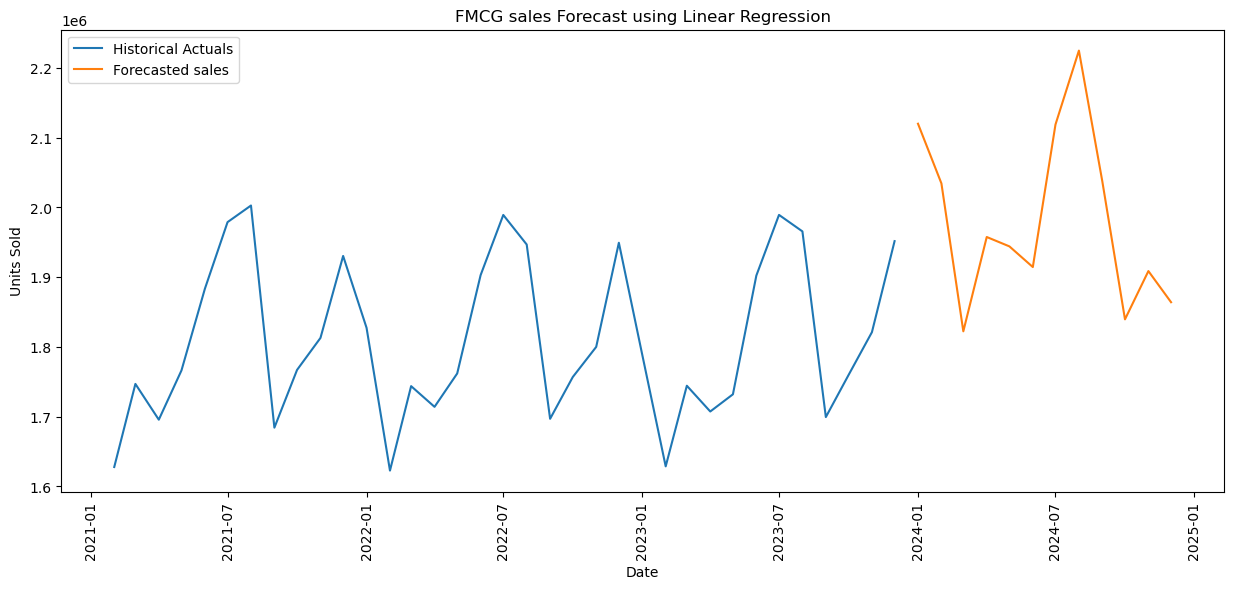

In [102]:
# Convert the strings back to datetime objects first
Monthly_sales['date'] = pd.to_datetime(Monthly_sales['date'])
forecast_df['date'] = pd.to_datetime(forecast_df['date'])


# Plotting the forecast
plt.figure(figsize=(15,6))
plt.plot(Monthly_sales['date'], Monthly_sales['units_sold'] ,label='Historical Actuals')
plt.plot(forecast_df['date'], forecast_df['Forecast_Sales'], label='Forecast sales')
plt.title('FMCG sales Forecast using Linear Regression')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend(['Historical Actuals','Forecasted sales'])
plt.xticks(rotation=90)
plt.savefig("Outputs/FMCG sales Forecast using Linear Regression.png")  # Saving the plot as png
plt.show()